Fitting OLS (no reg.) ...
Fitting Ridge ...
Fitting Lasso ...
Fitting ElasticNet ...
Evaluating Ridge (weak, α=1e-6) ...
Evaluating Lasso (weak, α=1e-6) ...
Evaluating ElasticNet (weak, α=1e-6) ...


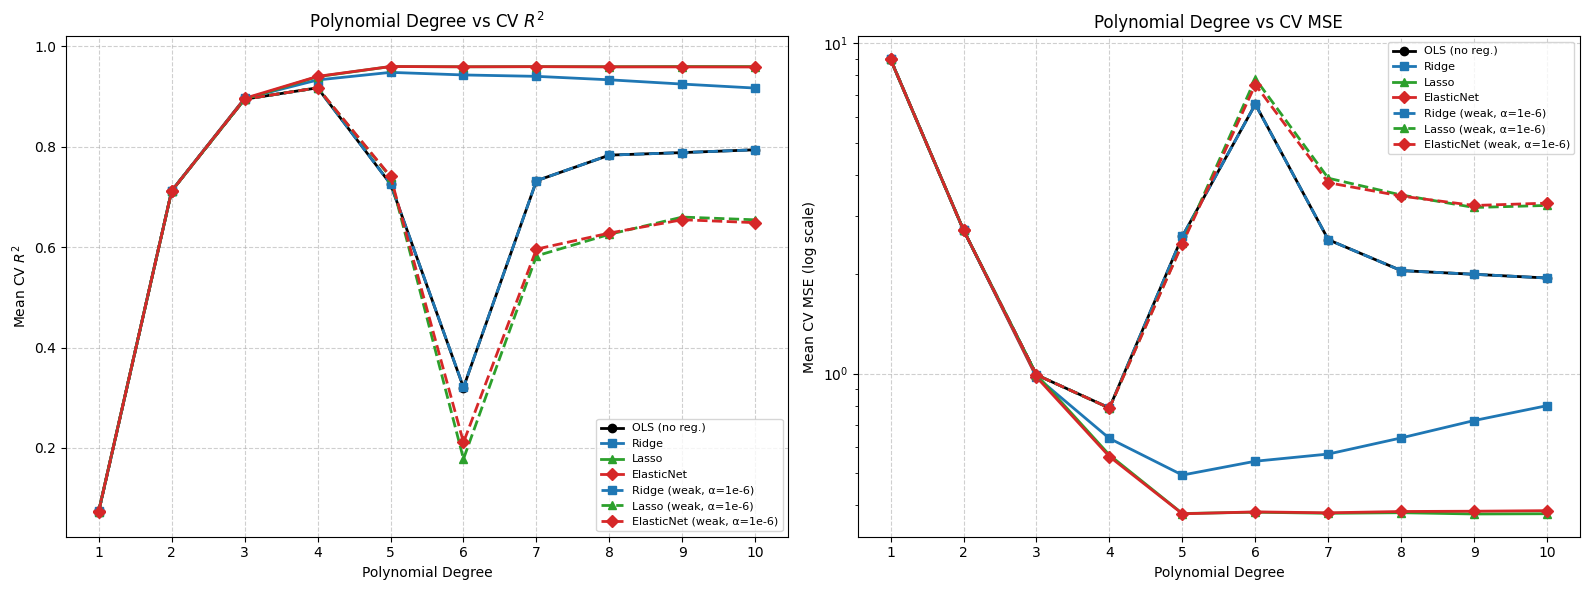


===== Model comparison (held-out test split) =====
        Model  Degree                           Params  CV R2  Test R2  Test MSE
        Lasso       5                  {'alpha': 0.01} 0.9600   0.9617  0.405859
   ElasticNet       5 {'alpha': 0.01, 'l1_ratio': 0.8} 0.9601   0.9598  0.426225
        Ridge       5                   {'alpha': 1.0} 0.9484   0.9510  0.519240
OLS (no reg.)       4                               {} 0.9176   0.9392  0.643597

Better model (lowest test MSE / highest test R2): Lasso
Saved predictions from Lasso to 'IMT2024078_predictions_best.csv'


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")

CV_FOLDS = 5
TOL = 0.001
DEGREES = list(range(1, 11))
ID = 'IMT2024078'

# ---------------- Data ----------------
df = pd.read_csv(f'{ID}_train_var1(in).csv')
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_unseen = pd.read_csv(f'{ID}_test_var1(in).csv').values

# ---------------- Model definitions ----------------
# (estimator, param grid for its hyperparameters)
models = {
    'OLS (no reg.)': (LinearRegression(), {}),
    'Ridge':         (Ridge(),            {'alpha': [0.1, 1.0, 10.0]}),
    'Lasso':         (Lasso(max_iter=10000), {'alpha': [0.01, 0.1, 1.0]}),
    'ElasticNet':    (ElasticNet(max_iter=10000),
                      {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]}),
}

# Weakly regularized versions: these are what expose overfitting at high degree
weak_models = {
    'Ridge (weak, α=1e-6)':      Ridge(alpha=1e-6),
    'Lasso (weak, α=1e-6)':      Lasso(alpha=1e-6, max_iter=10000),
    'ElasticNet (weak, α=1e-6)': ElasticNet(alpha=1e-6, l1_ratio=0.5, max_iter=10000),
}


def select_simplest(cv_results):
    """Lowest degree within TOL of best CV R2 (ties -> strongest regularization)."""
    d = pd.DataFrame(cv_results)
    d['deg'] = d['param_poly__degree'].astype(int)
    alpha_col = 'param_model__alpha'
    d['alp'] = d[alpha_col].astype(float) if alpha_col in d else 0.0
    best = d['mean_test_r2'].max()
    cand = d[d['mean_test_r2'] >= best - TOL].sort_values(['deg', 'alp'], ascending=[True, False])
    return int(cand.index[0])


# ---------------- Tuned models via GridSearchCV ----------------
fitted, curves = {}, {}
for name, (est, grid) in models.items():
    print(f"Fitting {name} ...")
    pg = {'poly__degree': DEGREES}
    pg.update({f'model__{k}': v for k, v in grid.items()})
    gs = GridSearchCV(
        Pipeline([('poly', PolynomialFeatures()), ('model', est)]),
        pg, cv=CV_FOLDS,
        scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error'},
        refit=select_simplest, n_jobs=-1)
    gs.fit(X_train, y_train)
    fitted[name] = gs

    res = pd.DataFrame(gs.cv_results_)
    best_deg = res.loc[res.groupby('param_poly__degree')['mean_test_r2'].idxmax()]
    curves[name] = (best_deg['param_poly__degree'].astype(int).values,
                    best_deg['mean_test_r2'].values,
                    -best_deg['mean_test_neg_mse'].values)

# ---------------- Weak-regularization curves (CV per degree) ----------------
from sklearn.model_selection import cross_validate
for name, est in weak_models.items():
    print(f"Evaluating {name} ...")
    r2s, mses = [], []
    for d in DEGREES:
        pipe = Pipeline([('poly', PolynomialFeatures(degree=d)), ('model', est)])
        cv = cross_validate(pipe, X_train, y_train, cv=CV_FOLDS,
                            scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error'}, n_jobs=-1)
        r2s.append(cv['test_r2'].mean())
        mses.append(-cv['test_neg_mse'].mean())
    curves[name] = (np.array(DEGREES), np.array(r2s), np.array(mses))

# ---------------- Single combined figure ----------------
styles = {
    'OLS (no reg.)': ('black', 'o', '-'),
    'Ridge': ('tab:blue', 's', '-'),
    'Lasso': ('tab:green', '^', '-'),
    'ElasticNet': ('tab:red', 'D', '-'),
    'Ridge (weak, α=1e-6)': ('tab:blue', 's', '--'),
    'Lasso (weak, α=1e-6)': ('tab:green', '^', '--'),
    'ElasticNet (weak, α=1e-6)': ('tab:red', 'D', '--'),
}
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for name, (deg, r2, mse) in curves.items():
    c, m, ls = styles[name]
    ax[0].plot(deg, r2, color=c, marker=m, linestyle=ls, linewidth=2, label=name)
    ax[1].plot(deg, mse, color=c, marker=m, linestyle=ls, linewidth=2, label=name)

ax[0].set_title('Polynomial Degree vs CV $R^2$')
ax[0].set_ylabel('Mean CV $R^2$')
ax[0].set_ylim(bottom=max(-1, min(c[1].min() for c in curves.values()) - 0.05), top=1.02)
ax[1].set_title('Polynomial Degree vs CV MSE')
ax[1].set_ylabel('Mean CV MSE (log scale)')
ax[1].set_yscale('log')
for a in ax:
    a.set_xlabel('Polynomial Degree'); a.set_xticks(DEGREES)
    a.grid(True, linestyle='--', alpha=0.6); a.legend(fontsize=8)
plt.tight_layout()
plt.savefig('degree_vs_r2_mse_all_models.png', dpi=150)
plt.show()

# ---------------- Compare tuned models on held-out test split ----------------
rows = []
for name, gs in fitted.items():
    pred = gs.best_estimator_.predict(X_test)
    rows.append({
        'Model': name,
        'Degree': gs.best_params_['poly__degree'],
        'Params': {k.replace('model__', ''): v for k, v in gs.best_params_.items() if k.startswith('model__')},
        'CV R2': round(pd.DataFrame(gs.cv_results_).loc[gs.best_index_, 'mean_test_r2'], 4),
        'Test R2': round(r2_score(y_test, pred), 4),
        'Test MSE': round(mean_squared_error(y_test, pred), 6),
    })
summary = pd.DataFrame(rows).sort_values('Test MSE')
print("\n===== Model comparison (held-out test split) =====")
print(summary.to_string(index=False))

winner = summary.iloc[0]['Model']
print(f"\nBetter model (lowest test MSE / highest test R2): {winner}")

# ---------------- Predictions from the winner ----------------
final_pred = fitted[winner].best_estimator_.predict(X_unseen)
pd.DataFrame({'Predicted_Net_Power_Score': final_pred}).to_csv(f'{ID}_predictions_best.csv', index=False)
print(f"Saved predictions from {winner} to '{ID}_predictions_best.csv'")